<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d0/Google_Play_Arrow_logo.svg/250px-Google_Play_Arrow_logo.svg.png" width="100">

# Google Play Store App Market Analysis

## Overview
**BLUF:** Entering the Android app market requires balancing category saturation, optimal pricing strategies (freemium models), and technical constraints (app size and minimum Android versions). This analysis leverages PySpark to process raw store metrics into a clean dataset, powering interactive dashboards to guide our startup's initial application deployment strategy.

## 1. Business Understanding
Our startup is entering the highly competitive mobile app market, initially targeting the Android/Google Play ecosystem. To maximize visibility and user acquisition, we must answer the following core business questions:
* **Category Dynamics:** Which app categories exhibit the highest installation volumes relative to market saturation?
* **Monetization Impact:** How do free versus paid pricing models influence user acquisition?
* **Technical Constraints:** What role do application size and content maturity ratings play in download success?

## 2. Data Understanding
The dataset, `google_play_store_dataset.csv`, contains metadata on app ratings, sizes, installs, and pricing. Initial exploration focuses on identifying null values (particularly in ratings) and type mismatches (string characters in numerical fields like Installs and Price) that require cleaning.

In [1]:
# Step 1 & 3: Imports and Initial Data Exploration
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("GooglePlayStoreAnalysis") \
    .getOrCreate()

# Load dataset
df = spark.read.csv("data/google_play_store_dataset.csv", header=True, inferSchema=True)

# Inspect Schema and Missing Values
df.printSchema()
df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df.columns]).show()

root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: string (nullable = true)
 |-- Reviews: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)

+---+--------+------+-------+----+--------+----+-----+--------------+------+------------+-----------+-----------+
|App|Category|Rating|Reviews|Size|Installs|Type|Price|Content Rating|Genres|Last Updated|Current Ver|Android Ver|
+---+--------+------+-------+----+--------+----+-----+--------------+------+------------+-----------+-----------+
|  0|       0|  1474|      0|   0|       0|   1|    0|             1|     0|           0|          8|          3|
+---+--------+------+--

## 3. Data Preparation
To prepare the data for analysis and visualization, we will:
1. Remove duplicate app entries.
2. Strip string characters (`+`, `,`, `$`) from numeric columns.
3. Cast `Installs`, `Price`, `Reviews`, and `Rating` to appropriate numeric datatypes.
4. Drop rows with null values in critical numerical fields to ensure data integrity.

In [2]:
# Step 4: Data Cleaning and Pipeline Execution
from pyspark.sql.functions import regexp_replace

# Clean string columns and cast to appropriate numeric types
df_clean = df.dropDuplicates(subset=['App']) \
    .withColumn("Installs", regexp_replace(col("Installs"), "[+,]", "").cast("int")) \
    .withColumn("Price", regexp_replace(col("Price"), "\\$", "").cast("double")) \
    .withColumn("Reviews", col("Reviews").cast("int")) \
    .withColumn("Rating", col("Rating").cast("float")) \
    .na.drop(subset=["Rating", "Installs", "Price", "Reviews"])

# Validate cleaned data
print(f"Cleaned Row Count: {df_clean.count()}")

# Save cleaned data file for Tableau usage
pandas_df = df_clean.toPandas()
pandas_df.to_csv("data/google_play_store_cleaned.csv", index=False)
print("Data successfully exported to 'data/google_play_store_cleaned.csv'.")

Cleaned Row Count: 8194
Data successfully exported to 'data/google_play_store_cleaned.csv'.


## 4. Data Analysis
Before transitioning to Tableau, we aggregate key metrics within the notebook to validate our logic and identify high-level trends.

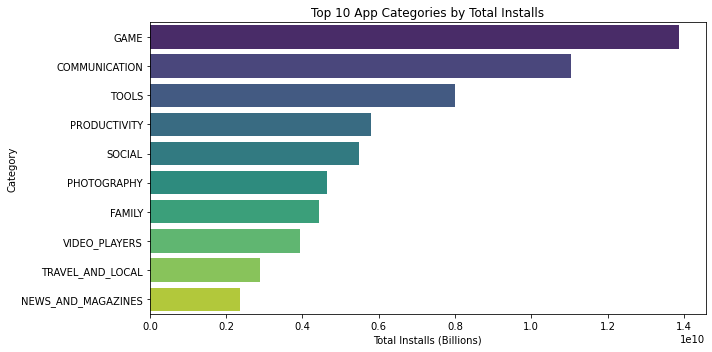

In [3]:
# Step 5: Initial Analysis and Visualization in Notebook
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, sum, mean

# Aggregate category performance using PySpark
category_performance = df_clean.groupBy("Category") \
    .agg(
        sum("Installs").alias("Total_Installs"),
        mean("Rating").alias("Average_Rating")
    ) \
    .orderBy(col("Total_Installs").desc()) \
    .limit(10)

# Convert small aggregated dataframe to Pandas for quick plotting
cat_pd = category_performance.toPandas()

# Plot Top 10 Categories by Installs
plt.figure(figsize=(10, 5))
sns.barplot(data=cat_pd, x='Total_Installs', y='Category', palette='viridis')
plt.title('Top 10 App Categories by Total Installs')
plt.xlabel('Total Installs (Billions)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## 5. Evaluation
The initial analysis confirms that categories like "Communication" and "Games" dominate installation volume. The data preparation phase successfully resolved formatting anomalies, meaning the exported dataset is robust enough to support reliable parameter controls and calculated fields in our final BI tool.

## 6. Deployment

### Link to Published Dashboard
The cleaned dataset powers a comprehensive, multi-page dashboard featuring interactive parameter controls for technical constraints and pricing. 

View the final deployment here:
[Play Store Market Analysis Dashboard](https://public.tableau.com/app/profile/eugin.wangila/viz/GooglePlayStore_17873912896100/GooglePlayStoreAppMarketInsights#1)

## Conclusion
By applying the CRISP-DM framework, we successfully transitioned raw Google Play Store data into an actionable intelligence asset. The PySpark cleaning pipeline standardized the metrics, and the resulting Tableau dashboard allows our startup's stakeholders to dynamically explore the market, ensuring our upcoming application is positioned in a viable category with an optimal pricing model.